<a href="https://colab.research.google.com/github/nidhisharma57350/Machine-Learning/blob/main/House_Price_Prediction_Using_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOUSE PRICE PREDICTION PROJECT USING LINEAR REGRESSION ALGORITHM

In [124]:
import pandas as pd

In [125]:
import numpy as np

In [126]:
import warnings
warnings.filterwarnings('ignore')

In [127]:
df=pd.read_csv("House_Data.csv")

In [128]:
print(df.head()) # It shows by default first 5 rows.

   Sqft  Bedrooms  Bathrooms  YearBuilt  LocationCode       Price
0  3774         2          4       2006             1  1279483.77
1  1460         4          4       1981             3   748298.12
2  1894         2          3       2020             1   768986.29
3  1730         5          4       1992             4   871720.14
4  1695         5          1       1988             5   834730.66


In [129]:
print(df.head(10)) # It shows first 10 rows(we can set number of rows according to our requirment.)

   Sqft  Bedrooms  Bathrooms  YearBuilt  LocationCode       Price
0  3774         2          4       2006             1  1279483.77
1  1460         4          4       1981             3   748298.12
2  1894         2          3       2020             1   768986.29
3  1730         5          4       1992             4   871720.14
4  1695         5          1       1988             5   834730.66
5  3692         1          1       2015             5  1420068.59
6  2238         5          4       2001             5  1140324.45
7  2769         1          2       2021             2   979032.52
8  1066         4          4       2005             1   556769.61
9  1838         2          4       1991             4   900678.83


In [130]:
print(df.tail()) # It shows by default bottom 5 rows.

     Sqft  Bedrooms  Bathrooms  YearBuilt  LocationCode       Price
995  2569         2          1       2015             2   857928.50
996   660         4          4       2010             4   570720.48
997  3281         1          2       1981             5  1279230.12
998  3722         1          3       1995             3  1435726.90
999  1628         5          3       1988             5   953762.59


In [131]:
print(df.tail(10)) # It shows bottom 10 rows(we can set number of rows according to our requirment.)

     Sqft  Bedrooms  Bathrooms  YearBuilt  LocationCode       Price
990  2487         3          2       2020             3   992780.09
991  3866         2          2       1992             1  1292977.53
992  1266         3          3       1997             4   644628.69
993   692         2          1       2016             3   365953.88
994  1271         5          2       1992             3   674085.30
995  2569         2          1       2015             2   857928.50
996   660         4          4       2010             4   570720.48
997  3281         1          2       1981             5  1279230.12
998  3722         1          3       1995             3  1435726.90
999  1628         5          3       1988             5   953762.59


In [132]:
print(df.info()) # It gives all the information about the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sqft          1000 non-null   int64  
 1   Bedrooms      1000 non-null   int64  
 2   Bathrooms     1000 non-null   int64  
 3   YearBuilt     1000 non-null   int64  
 4   LocationCode  1000 non-null   int64  
 5   Price         1000 non-null   float64
dtypes: float64(1), int64(5)
memory usage: 47.0 KB
None


In [133]:
print(df.isnull()) # It shows there are null values in the dataset or not.(if yes then it return True else False)

      Sqft  Bedrooms  Bathrooms  YearBuilt  LocationCode  Price
0    False     False      False      False         False  False
1    False     False      False      False         False  False
2    False     False      False      False         False  False
3    False     False      False      False         False  False
4    False     False      False      False         False  False
..     ...       ...        ...        ...           ...    ...
995  False     False      False      False         False  False
996  False     False      False      False         False  False
997  False     False      False      False         False  False
998  False     False      False      False         False  False
999  False     False      False      False         False  False

[1000 rows x 6 columns]


In [134]:
print(df.isnull().sum()) # It returns the total number of null values in each column.

Sqft            0
Bedrooms        0
Bathrooms       0
YearBuilt       0
LocationCode    0
Price           0
dtype: int64


In [135]:
print(df.describe()) # It returns the statistics of the dataset.

              Sqft     Bedrooms    Bathrooms    YearBuilt  LocationCode  \
count  1000.000000  1000.000000  1000.000000  1000.000000   1000.000000   
mean   2338.002000     2.976000     2.483000  2001.104000      3.001000   
std     989.801851     1.421775     1.135341    12.175032      1.421626   
min     601.000000     1.000000     1.000000  1980.000000      1.000000   
25%    1476.750000     2.000000     1.000000  1991.000000      2.000000   
50%    2294.000000     3.000000     2.000000  2001.000000      3.000000   
75%    3276.250000     4.000000     4.000000  2012.000000      4.000000   
max    3998.000000     5.000000     4.000000  2022.000000      5.000000   

              Price  
count  1.000000e+03  
mean   9.514299e+05  
std    3.071842e+05  
min    2.548069e+05  
25%    6.846308e+05  
50%    9.372101e+05  
75%    1.208772e+06  
max    1.614792e+06  


In [136]:
import matplotlib.pyplot as plt

In [137]:
import seaborn as sns

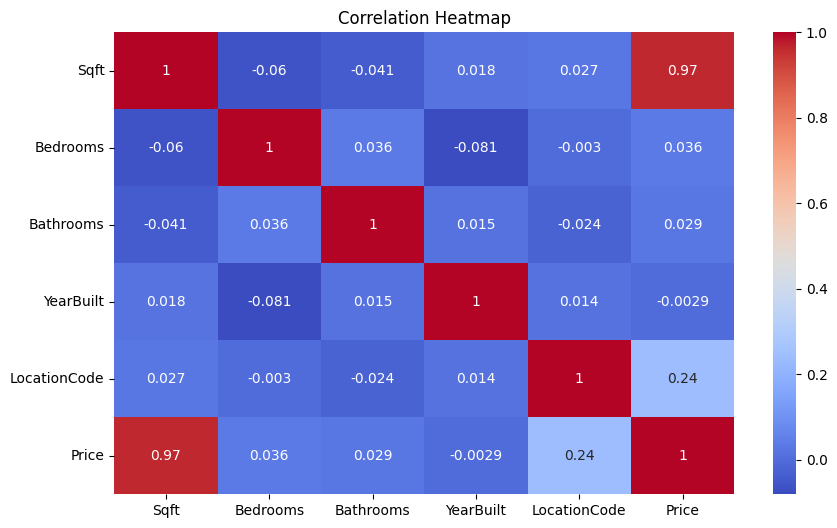

In [138]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(numeric_only = True),annot = True,cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

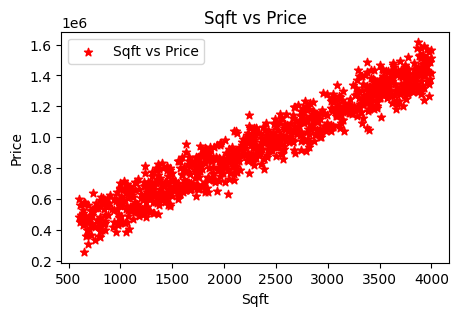

In [139]:
plt.figure(figsize=(5,3))
plt.scatter(df["Sqft"],df["Price"],marker = "*",color = "red",label = "Sqft vs Price")
plt.xlabel("Sqft")
plt.ylabel("Price")
plt.title("Sqft vs Price")
plt.legend(loc = "upper left")
plt.show()

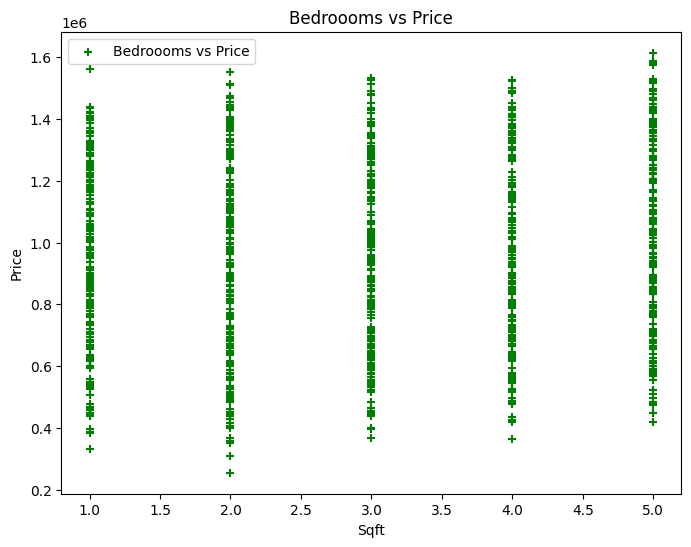

In [140]:
plt.figure(figsize=(8,6))
plt.scatter(df["Bedrooms"],df["Price"],marker = "+",color = "green",label = "Bedroooms vs Price")
plt.xlabel("Sqft")
plt.ylabel("Price")
plt.title("Bedroooms vs Price")
plt.legend(loc = "upper left")
plt.show()

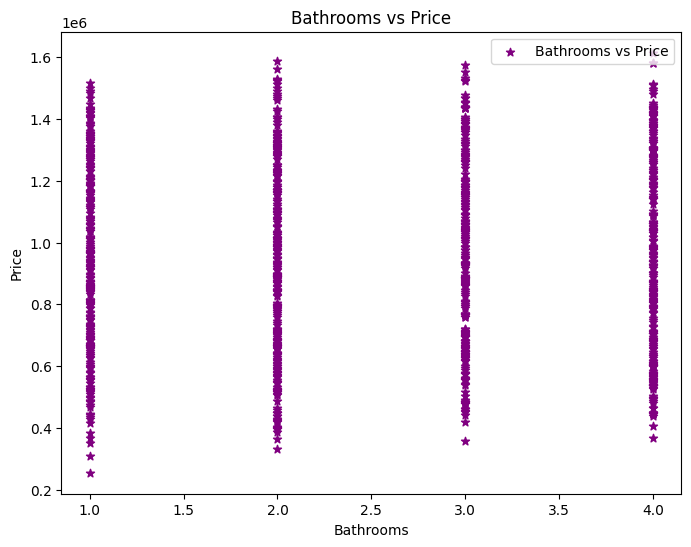

In [141]:
plt.figure(figsize=(8,6))
plt.scatter(df["Bathrooms"],df["Price"],marker = "*",color = "purple",label="Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.title("Bathrooms vs Price")
plt.legend(loc = "upper right")
plt.show()

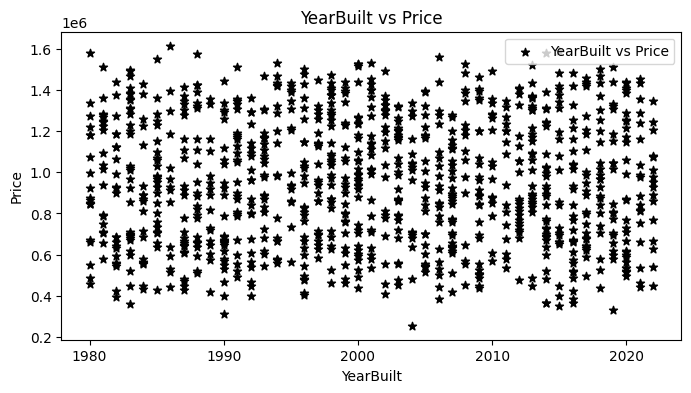

In [142]:
plt.figure(figsize=(8,4))
plt.scatter(df["YearBuilt"],df["Price"],marker = "*",color = "black",label="YearBuilt vs Price")
plt.xlabel("YearBuilt")
plt.ylabel("Price")
plt.title("YearBuilt vs Price")
plt.legend(loc = "upper right")
plt.show()

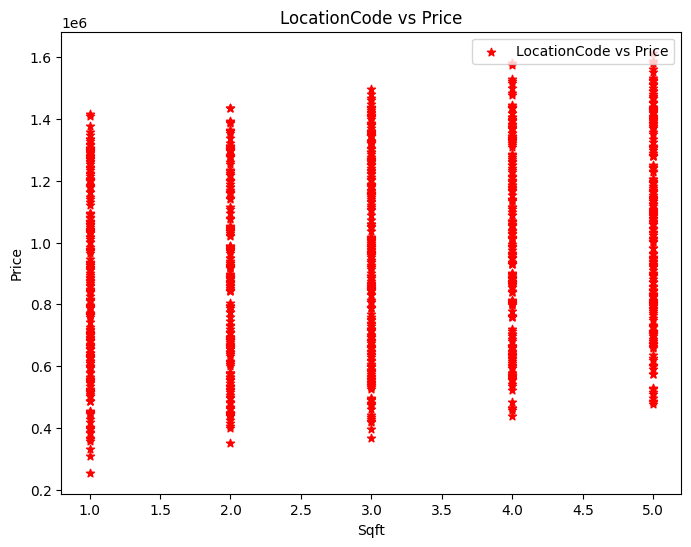

In [143]:
plt.figure(figsize=(8,6))
plt.scatter(df["LocationCode"],df["Price"],marker = "*",color = "red",label = "LocationCode vs Price")
plt.xlabel("Sqft")
plt.ylabel("Price")
plt.title("LocationCode vs Price")
plt.legend(loc = "upper right")
plt.show()

In [144]:
x = df[["Sqft","Bedrooms","Bathrooms","YearBuilt","LocationCode"]] # Input Variables

In [145]:
y = df["Price"] # Output Variable

In [146]:
from sklearn.model_selection import train_test_split

In [147]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state = 42) # 80% data splits in training and 20% in testing.

In [148]:
print(x_train.shape)

(800, 5)


In [149]:
print(len(x_train))

800


In [150]:
print(x_test.shape)

(200, 5)


In [151]:
print(len(x_test))

200


In [152]:
print(y_train.shape)

(800,)


In [153]:
print(len(y_train))

800


In [154]:
print(y_test.shape)

(200,)


In [155]:
print(len(y_test))

200


In [156]:
from sklearn.linear_model import LinearRegression

In [157]:
model = LinearRegression()

In [158]:
model.fit(x_train,y_train)

LinearRegression()

In [159]:
y_pred = model.predict(x_test)

In [160]:
import numpy as np

In [161]:
user_input = np.array([[4000,3,4,2000,2]])

In [162]:
user_prediction = model.predict(user_input)

In [163]:
print(user_prediction)

[1435661.75146374]


In [164]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [165]:
mae = mean_absolute_error(y_test,y_pred)

In [166]:
print("mean absolute error:",mean_absolute_error(y_test,y_pred))

mean absolute error: 25992.829544607317


In [167]:
mse = mean_absolute_error(y_test,y_pred)

In [168]:
print("mean squared error:",mean_squared_error(y_test,y_pred))

mean squared error: 1077619396.5800586


In [169]:
rmse = root_mean_squared_error(y_test,y_pred)

In [170]:
print("root mean squared error:",root_mean_squared_error(y_test,y_pred))

root mean squared error: 32827.1137412362


In [171]:
r2_score = r2_score(y_test,y_pred)

In [172]:
print("r2 score:",r2_score)

r2 score: 0.9888245851717383
